# AGA Diagram Generation Testing Notebook
This notebook tests the diagram generation capabilities of the Architecture Generation Agent (AGA) module using the `raa_output.pkl` sample data.

In [1]:
import sys
import os

# Add the parent directory to the path so we can import 'aga'
sys.path.append(os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import pickle
from pprint import pprint
from aga import AGAConfig, build_graph
from aga.normaliser import NormalisationError
from langchain_openai import ChatOpenAI

In [3]:

# 1. Load RAA output from checkpoint
raa_output_path = "raa_output.pkl"
with open(raa_output_path, "rb") as f:
    raa_dict = pickle.load(f)

print(f"Loaded RAA output with keys: {list(raa_dict.keys())}")

Loaded RAA output with keys: ['l1_description', 'l2_descriptions', 'l3_descriptions', 'entity_registry', 'coverage_gaps', 'conflicts']


In [4]:
DEEPSEEK_API_KEY = os.environ.get("DEEPSEEK_API_KEY")
if not DEEPSEEK_API_KEY:
    raise RuntimeError("Set DEEPSEEK_API_KEY in your environment before running.")

llm = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0.0,
    api_key=DEEPSEEK_API_KEY,
    base_url="https://api.deepseek.com",
    reasoning_effort="high",
    extra_body={"thinking": {"type": "enabled"}},
)

 
# 2. Construct configuration
output_dir = "aga_output"
config = AGAConfig(
    llm=llm,
    max_retries=5,
    plantuml_base_url="https://www.plantuml.com/plantuml",
    output_dir=output_dir,
)

# 3. Build the graph
graph = build_graph(config)

In [5]:
# 4. Invoke the graph (Stream progress)
print("Starting diagram generation...")
final_result = None
try:
    # Stream to see progress as it happens
    for chunk in graph.stream(
        {"raa_output": raa_dict},
        stream_mode="values",
        output_keys=["completed_diagrams", "failed_diagrams", "session_report"],
    ):
        c = len(chunk.get("completed_diagrams", []))
        f = len(chunk.get("failed_diagrams", []))
        if "session_report" in chunk:
            print(f"Done: {chunk['session_report'].completed_count} completed, "
                  f"{chunk['session_report'].failed_count} failed")
            final_result = chunk
        else:
            print(f"Progress: {c} completed, {f} failed so far")
except NormalisationError as e:
    print(f"RAA output is malformed — cannot render diagrams: {e}")

Starting diagram generation...
Progress: 0 completed, 0 failed so far
Progress: 1 completed, 0 failed so far
Progress: 2 completed, 0 failed so far
Progress: 3 completed, 0 failed so far
Progress: 4 completed, 0 failed so far
Progress: 5 completed, 0 failed so far
Progress: 6 completed, 0 failed so far
Progress: 7 completed, 0 failed so far
Done: 7 completed, 0 failed


In [6]:
# 5. Inspect results
if final_result:
    report = final_result["session_report"]
    print(f"AGA complete: {report.completed_count}/{report.total_diagrams_expected} "
          f"diagrams rendered in {report.wall_clock_seconds:.1f}s")

    if final_result.get("failed_diagrams"):
        print("\nFailed Diagrams:")
        for fd in final_result["failed_diagrams"]:
            print(f"  FAILED {fd.diagram_id}: {fd.last_error[:120]}")
else:
    print("No result was produced.")

AGA complete: 7/7 diagrams rendered in 398.2s


### ctx (context)

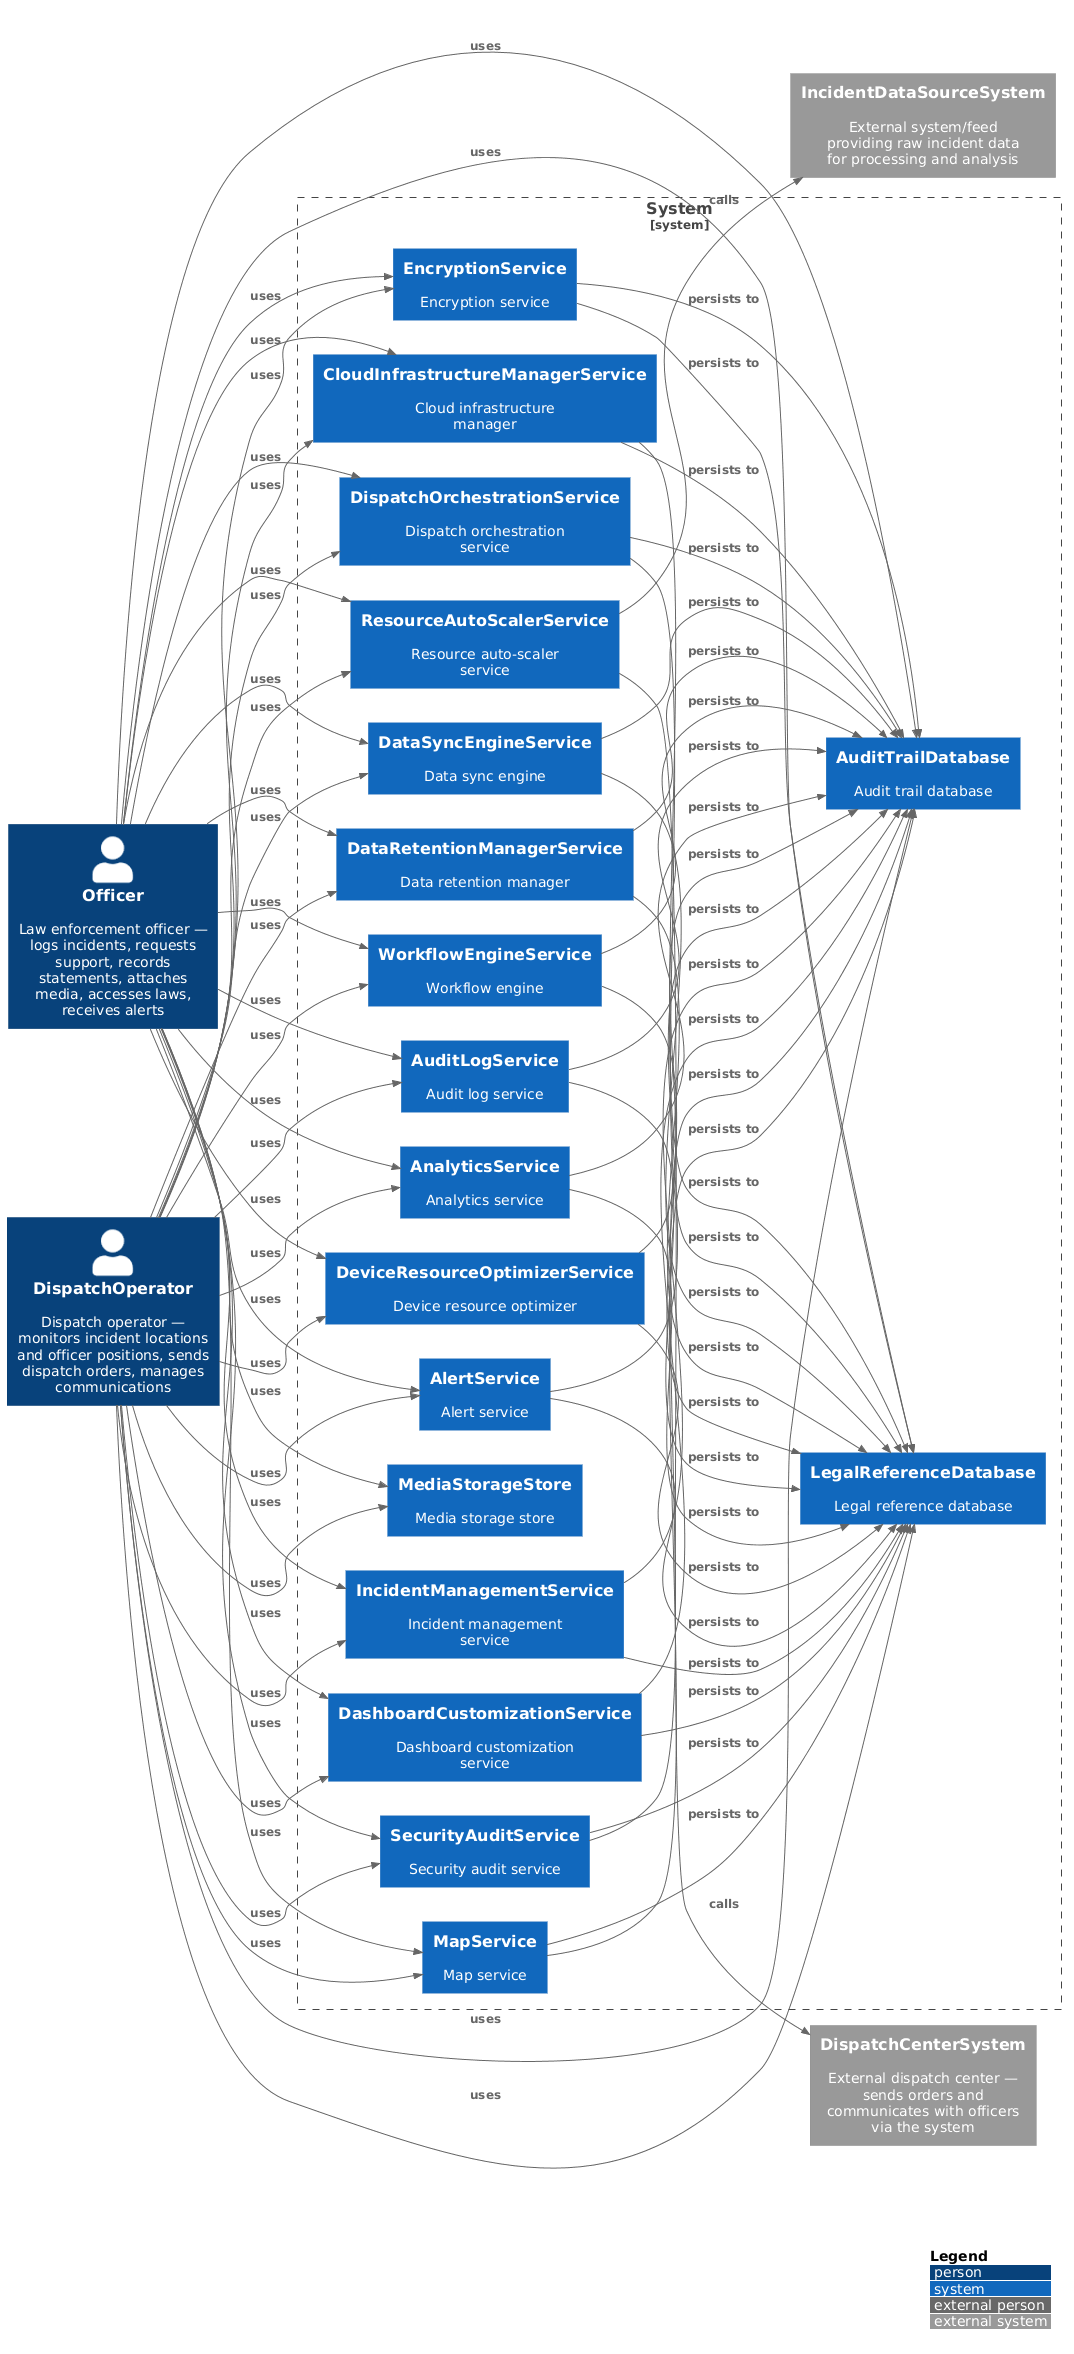

Retries: 0
---


### cnt-concern_batch_1 (container)

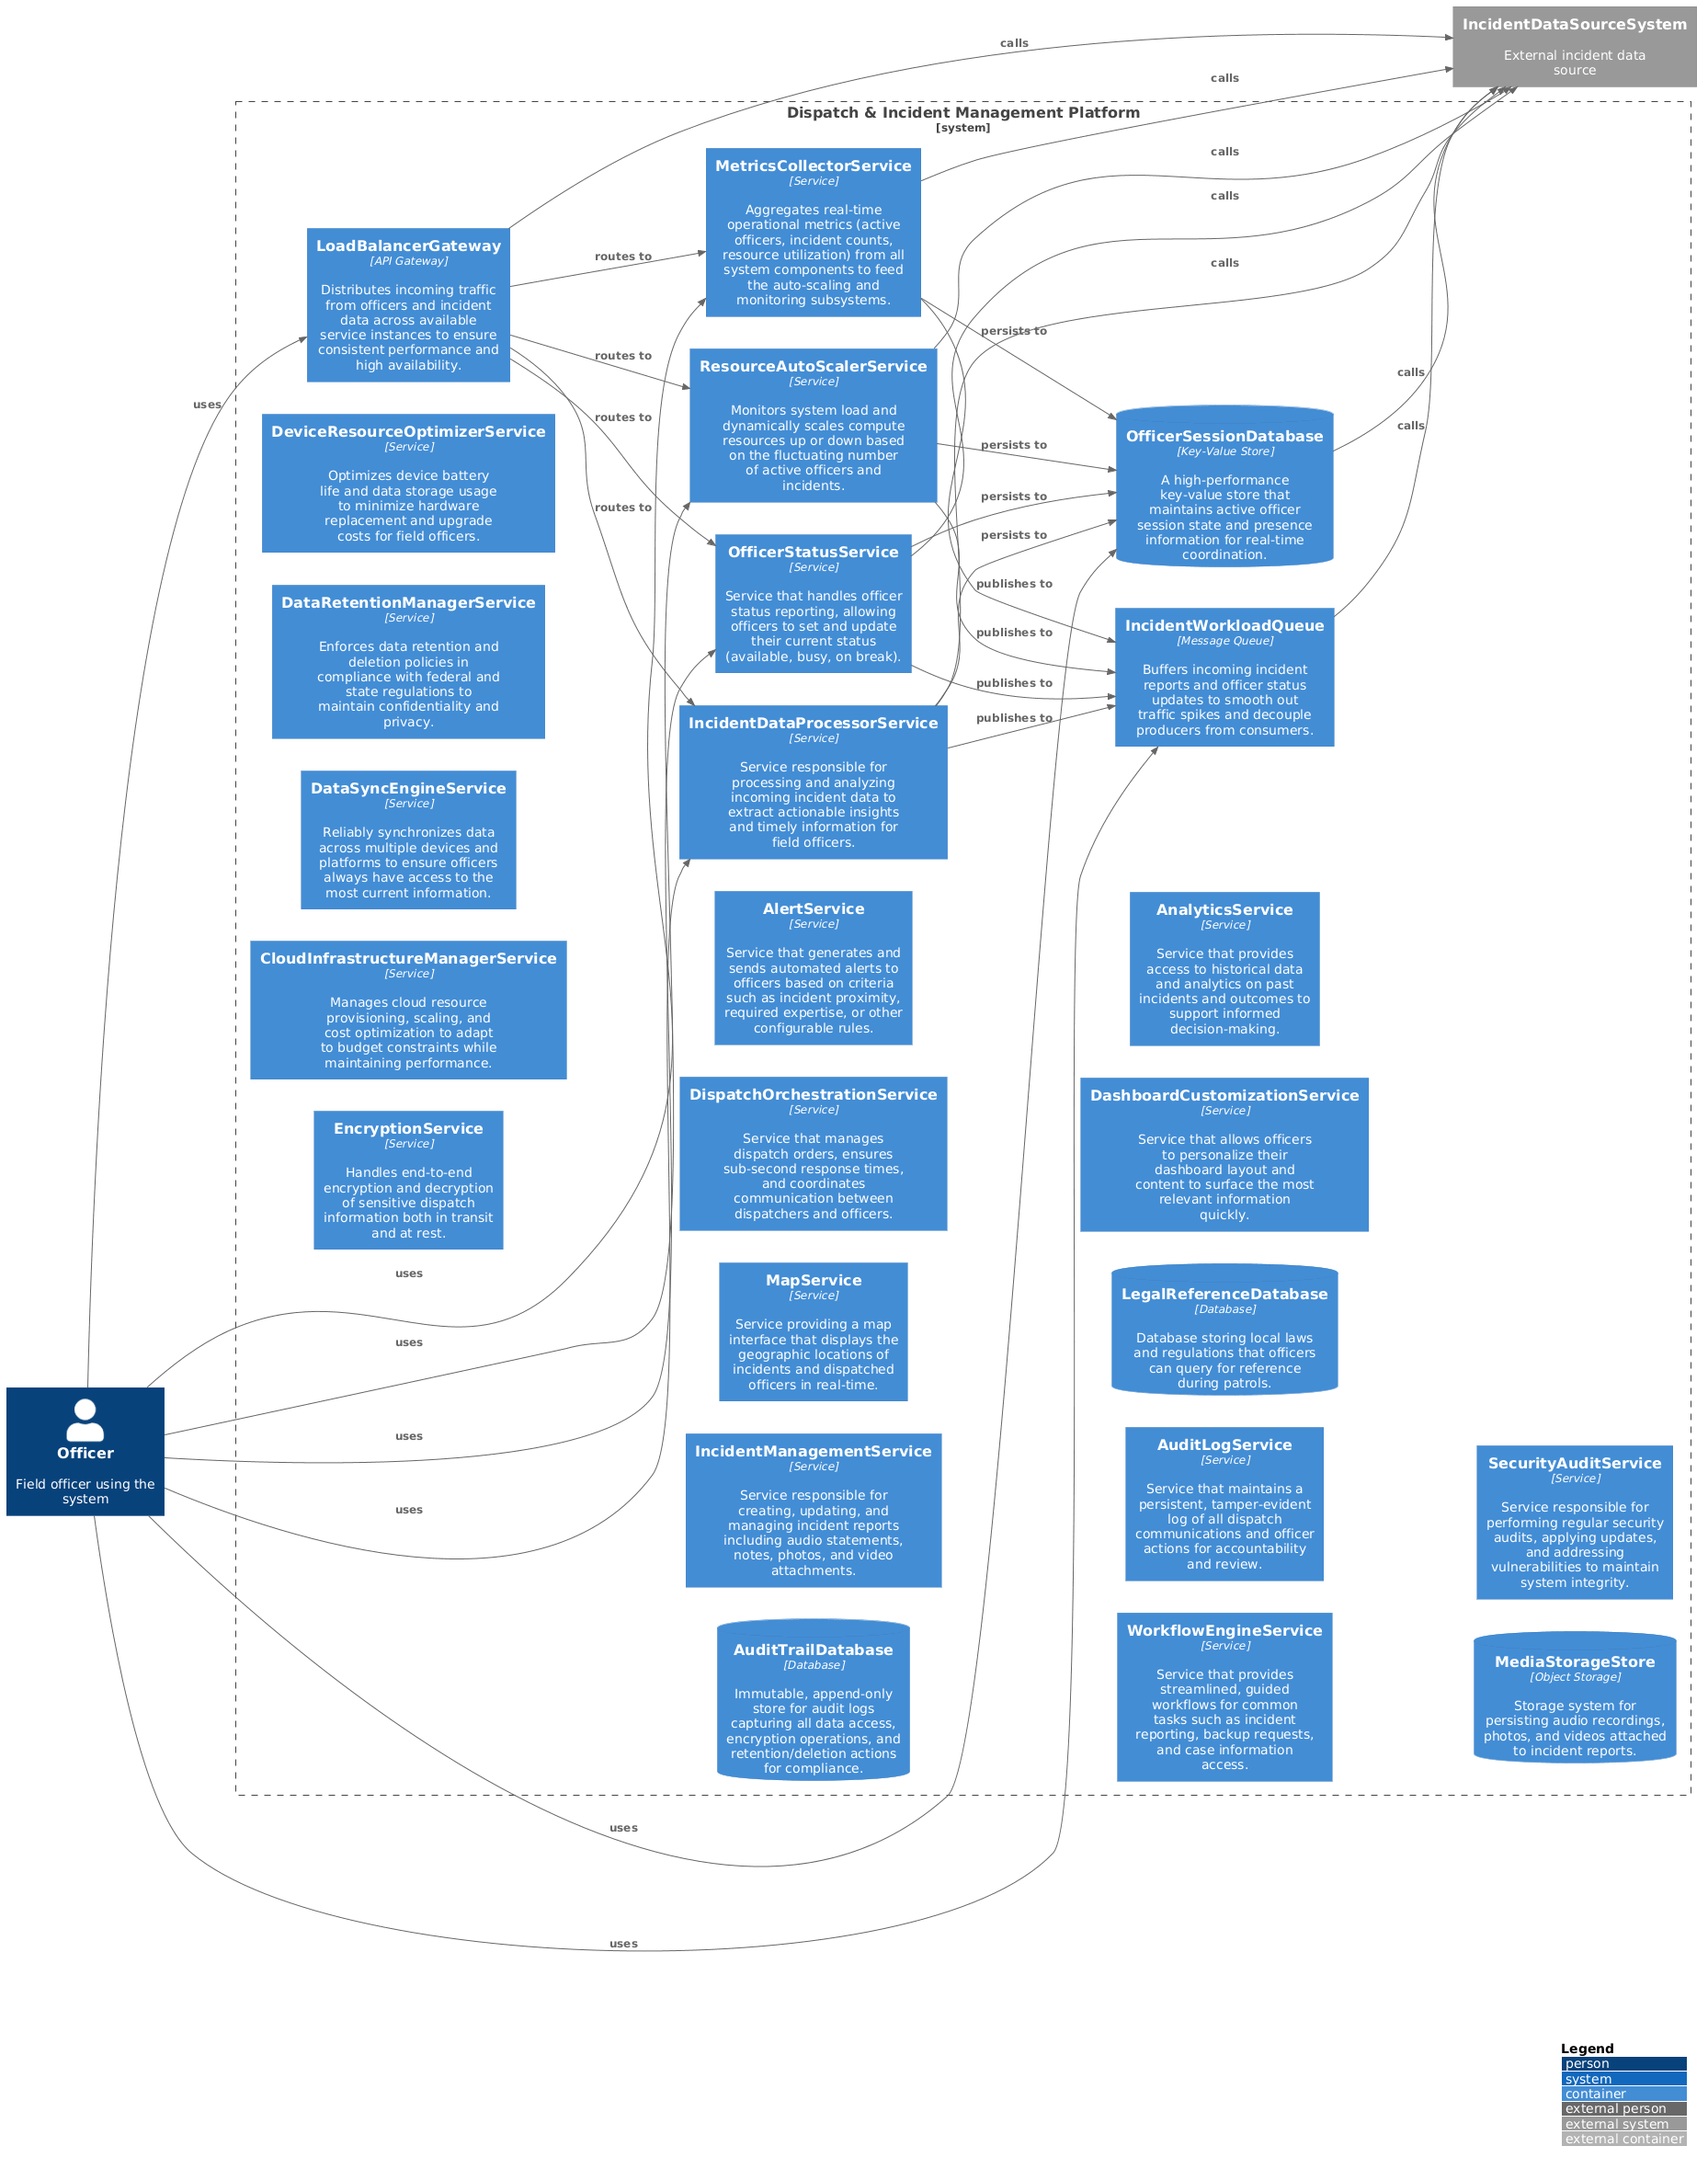

Retries: 0
---


### cnt-concern_batch_2 (container)

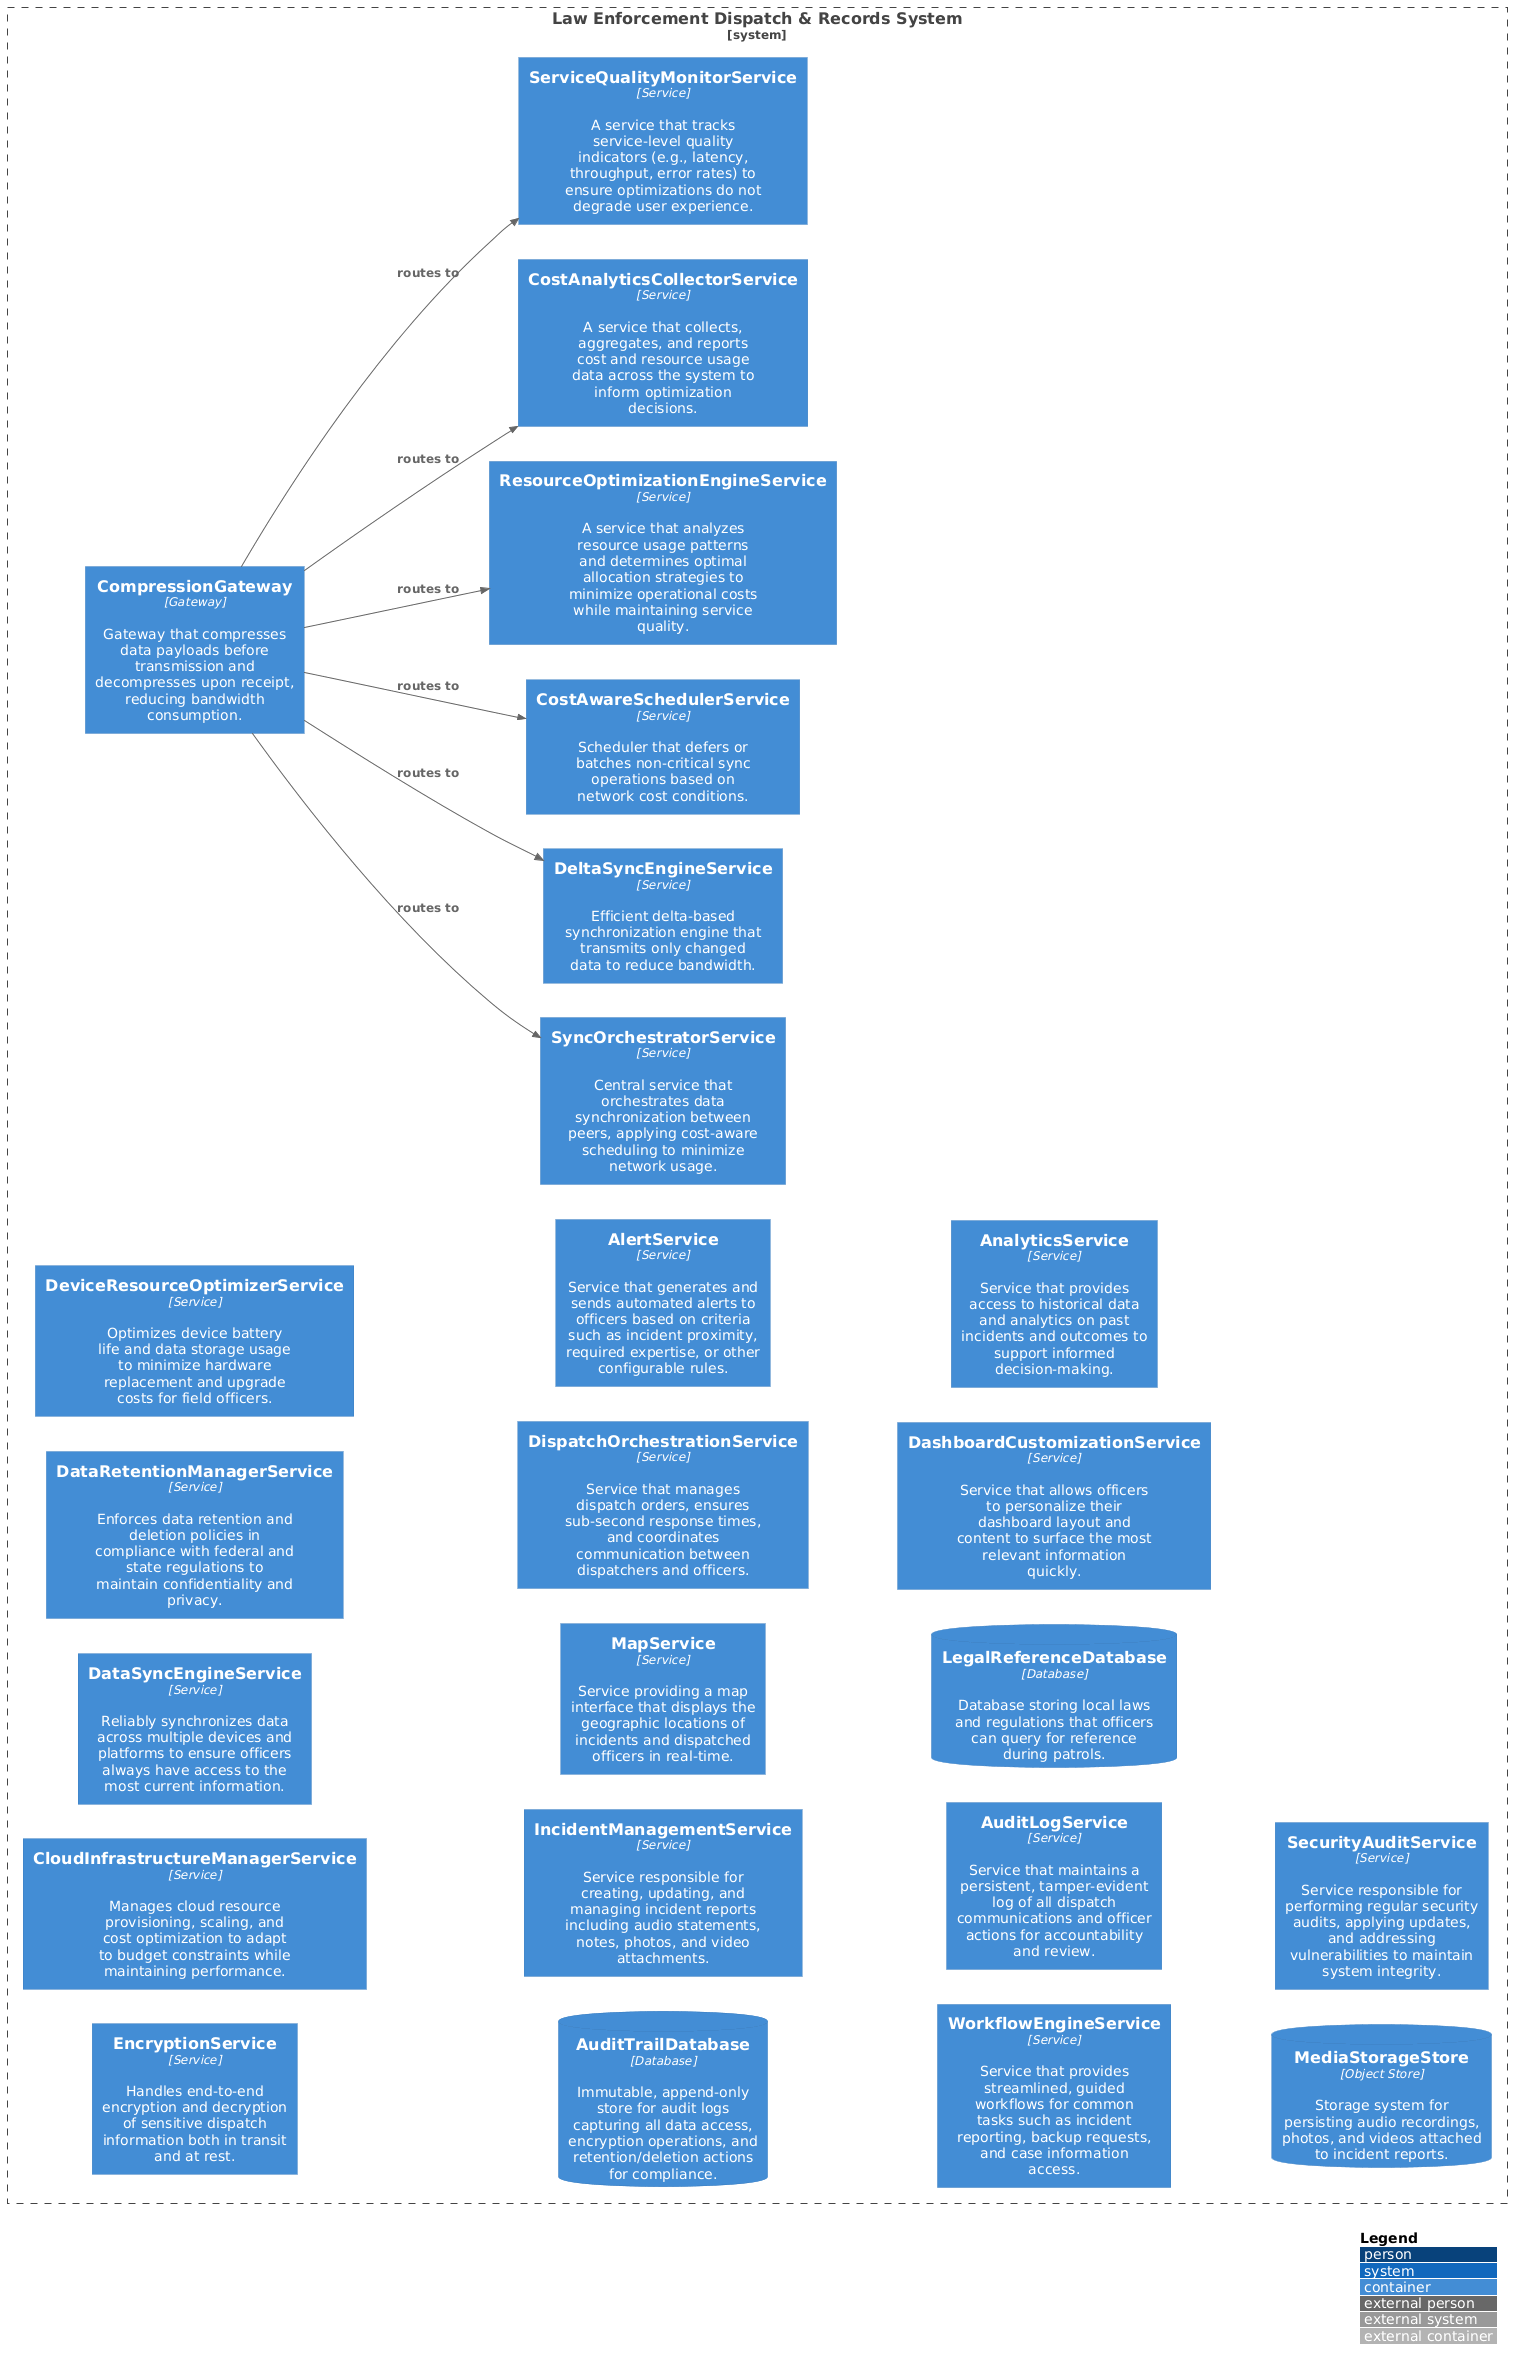

Retries: 0
---


### cnt-concern_batch_3 (container)

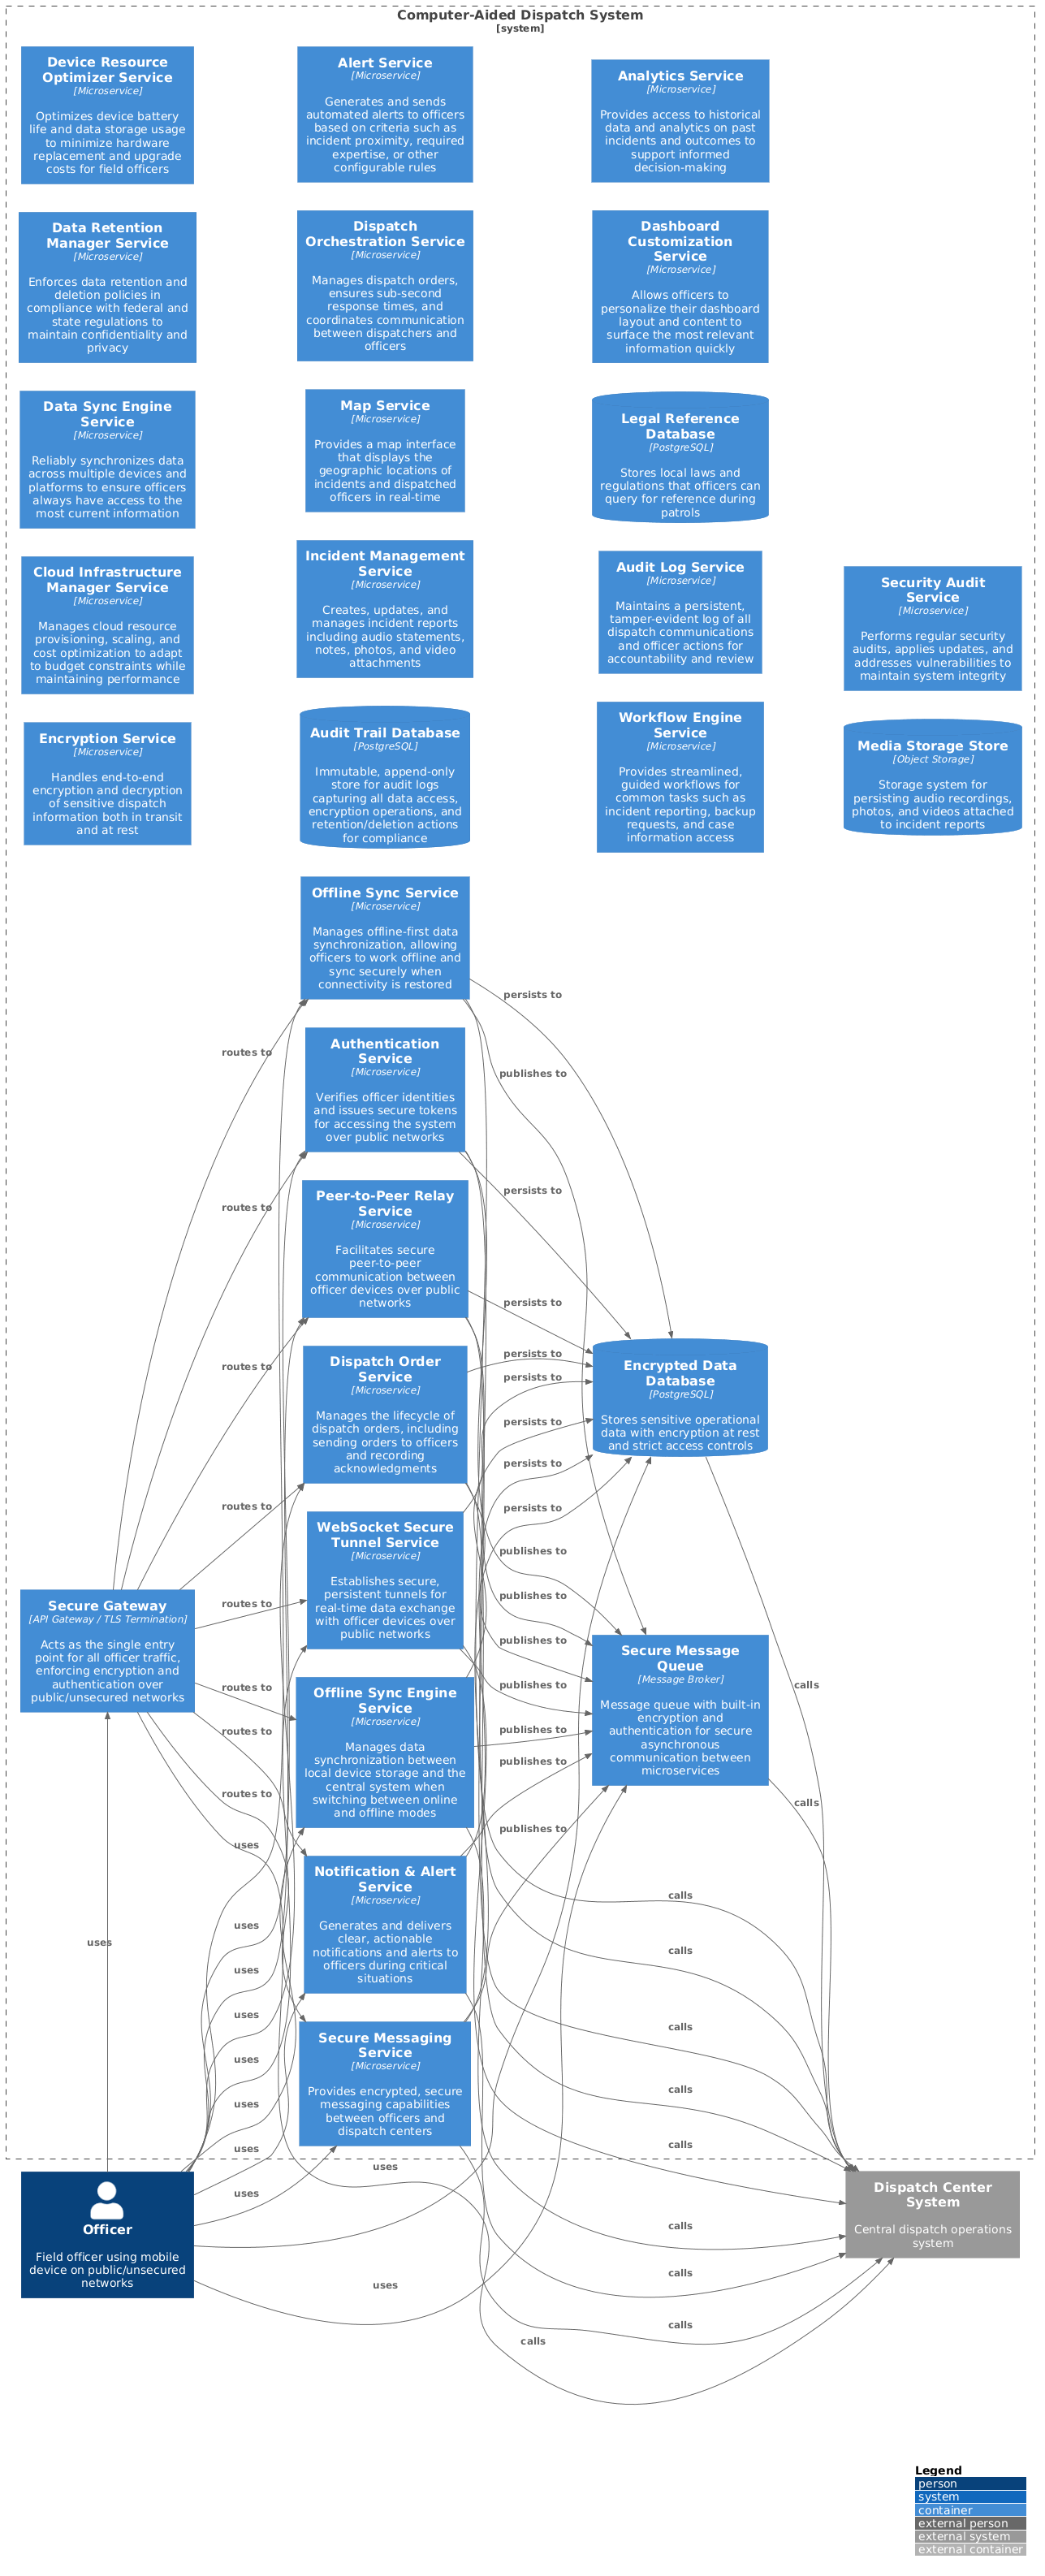

Retries: 0
---


### cnt-concern_batch_4 (container)

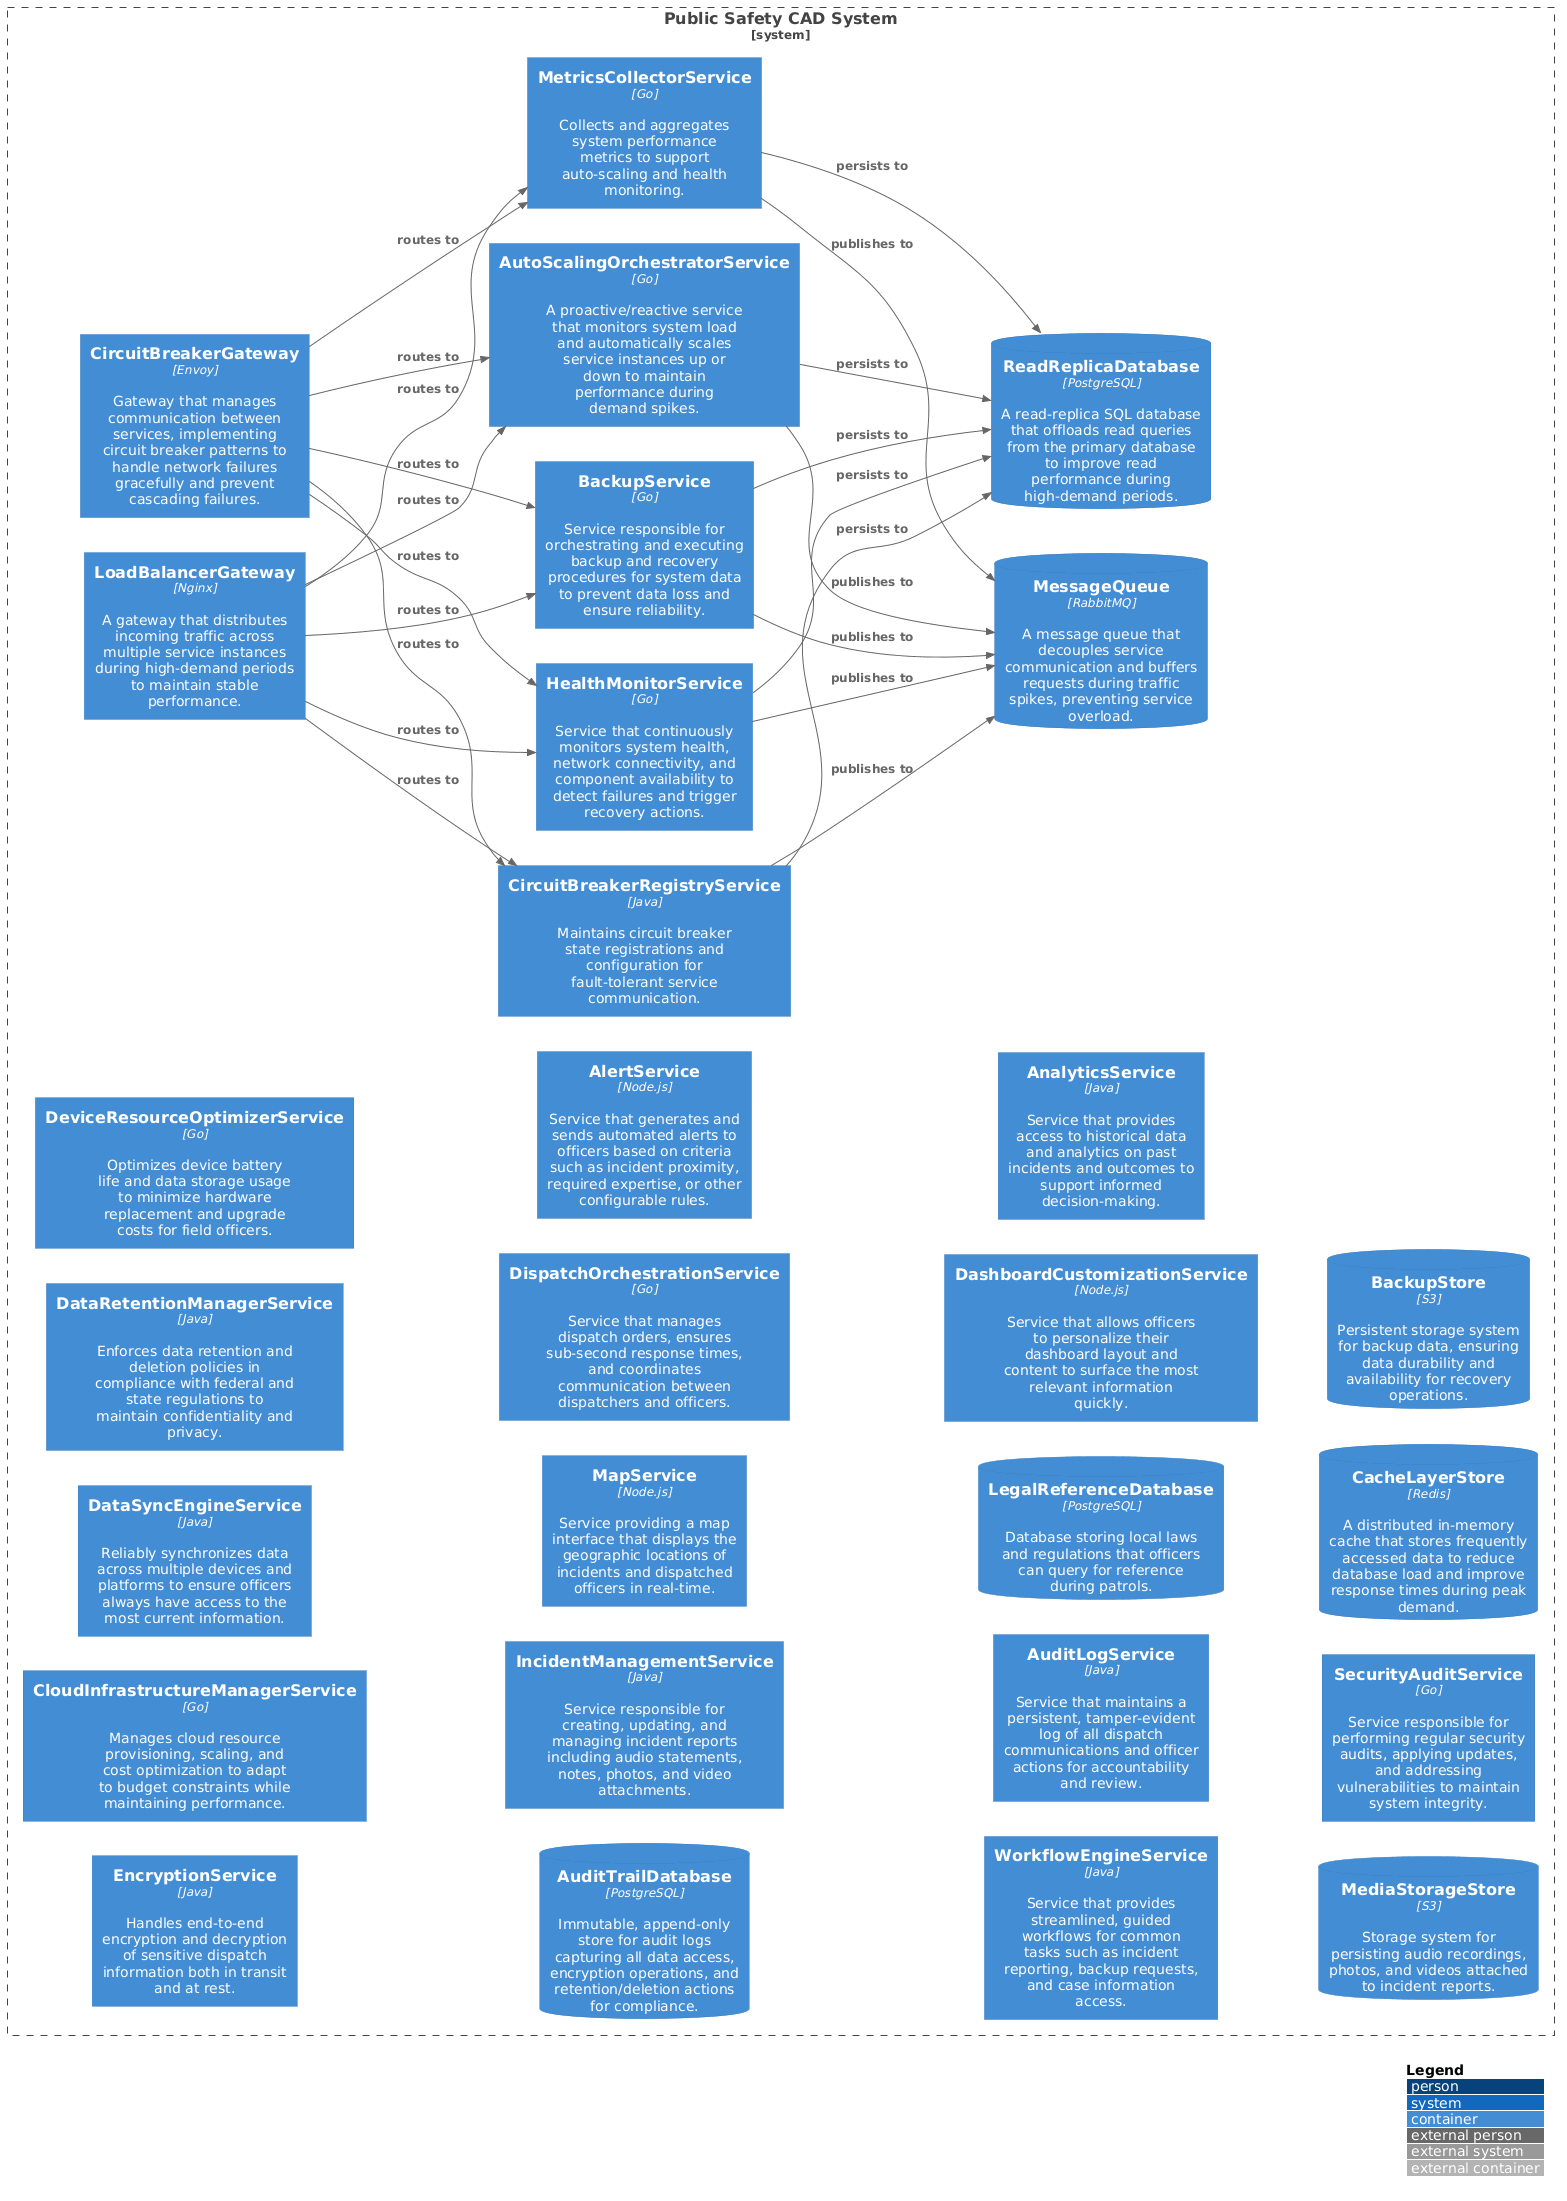

Retries: 0
---


### cmp-ENT-010-concern_batch_2 (component)

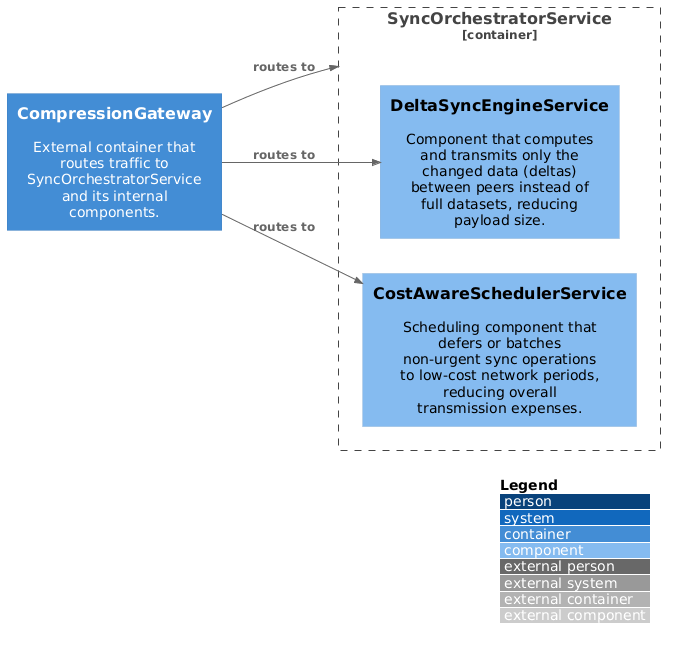

Retries: 0
---


### cmp-ENT-002-concern_batch_4 (component)

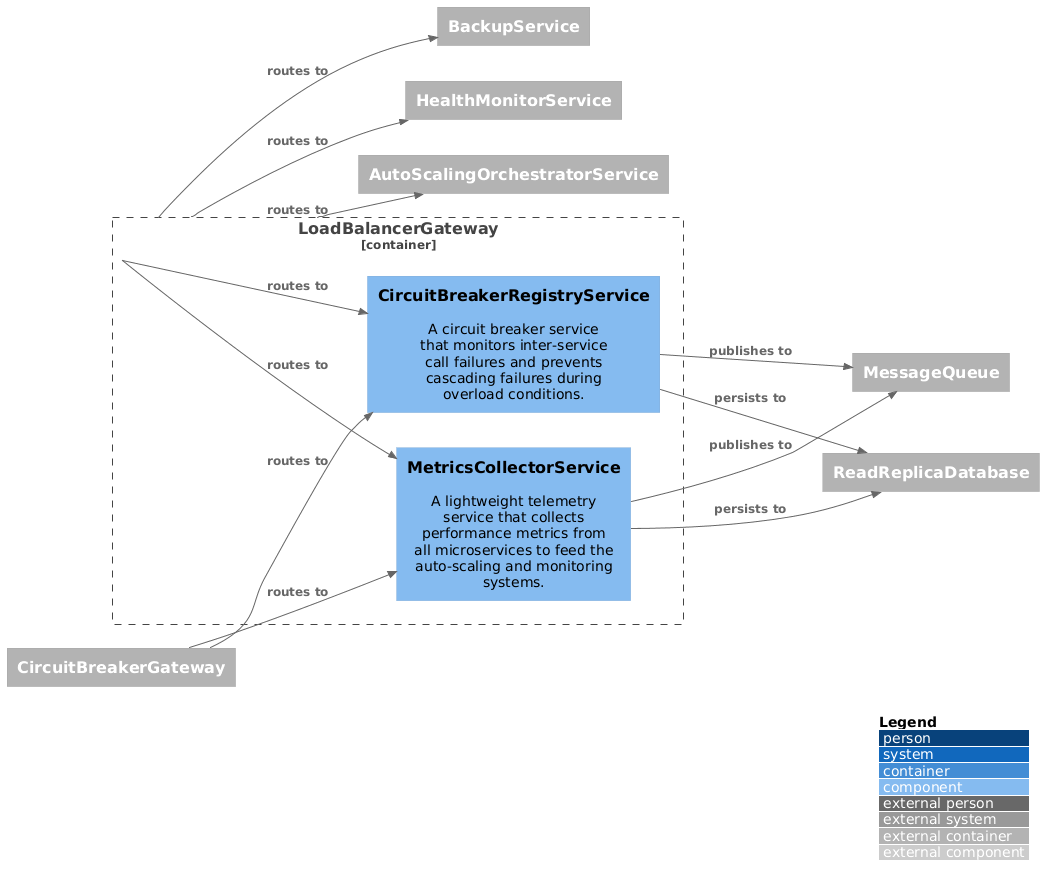

Retries: 0
---


In [7]:
from IPython.display import Image, display, Markdown
import os

# 6. Display generated diagrams
if final_result and final_result.get("completed_diagrams"):
    for cd in final_result["completed_diagrams"]:
        display(Markdown(f"### {cd.diagram_id} ({cd.diagram_type})"))
        if os.path.exists(cd.output_path):
            display(Image(filename=cd.output_path))
        else:
            print(f"Could not find image at: {cd.output_path}")
        print(f"Retries: {cd.retry_count}")
        print("---")